<a href="https://colab.research.google.com/github/viongaard/data_analysis/blob/develop/students_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ данных датасета "Students Data Analysis"
## Автор: Вожегов Алексей
## 1. Введение
Данный проект посвящен исследовательскому анализу данных (EDA) и построению моделей машинного обучения для прогнозирования академической успеваемости студентов.
### 1.1 Актуальность
В современном образовании анализ успеваемости студентов позволяет:
- выявить ключевые факторы, влияющие на академическую успеваемость;
- своевременно определять студентов из группы риска;
- оптимизировать учебные программы;
- разрабатывать персонализированные подходы к обучению.
### 1.2 Источник данных
Датасет взят с Kaggle: https://www.kaggle.com/datasets/erqizhou/students-data-analysis

## 2. Цель и задачи
Цель: провести комплексный анализ данных студентов и построить модель для прогнозирования целевой переменной (успеваемости/поступления).
Задачи:

### 2.1. Задачи исследовательского анализа (EDA):
1. **Загрузка и первичный анализ данных**
   - Оценка размера и структуры датасета
   - Изучение типов данных
   - Выявление пропусков и дубликатов

2. **Анализ распределений**
   - Изучение распределения числовых признаков
   - Анализ категориальных переменных
   - Выявление выбросов

3. **Корреляционный анализ**
   - Построение корреляционной матрицы
   - Выявление взаимосвязей между предметами
   - Определение факторов, влияющих на целевую переменную

4. **Визуализация данных**
   - Построение гистограмм и boxplot
   - Визуализация корреляций
   - Групповые сравнения

### 2.2. Задачи предобработки данных:
1. **Обработка пропусков** (при наличии)
2. **Обработка выбросов** (методом каппинга)
3. **Кодирование категориальных признаков**
   - One-Hot Encoding для бинарных категорий
   - Frequency Encoding для многоклассовых категорий
4. **Создание новых признаков (Feature Engineering)**
   - Статистики по оценкам (среднее, std, min, max)
   - Индекс сложности предметов
   - Признаки взаимодействия
   - Логарифмические преобразования

### 2.3. Задачи моделирования:
1. **Построение базовых моделей машинного обучения:**
   - Логистическая регрессия
   - Random Forest
   - Gradient Boosting

2. **Оценка качества моделей:**
   - Accuracy
   - F1-score (macro и weighted)
   - Classification Report
   - Confusion Matrix

3. **Анализ важности признаков**
   - Определение ключевых предикторов
   - Интерпретация результатов

## Импорт библиотек и загрузка данных
в датасете мало данных - всего 105 записей и 17 колонок

In [1]:
import kagglehub
import pandas as pd
import os

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Загрузка данных
path = kagglehub.dataset_download("erqizhou/students-data-analysis")
df = pd.read_csv(os.path.join(path, 'Students data.csv'))

print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nПервые 5 строк:\n{df.head()}")

100%|██████████| 2.12k/2.12k [00:00<00:00, 1.04MB/s]

Extracting files...
Размер: (105, 17)
Колонки: ['ID', 'class', 'gender', 'race', 'GPA', 'Algebra', 'Calculus1', 'Calculus2', 'Statistics', 'Probability', 'Measure', 'Functional_analysis', 'from1', 'from2', 'from3', 'from4', 'y']

Первые 5 строк:
     ID class  gender  race    GPA  Algebra  Calculus1  Calculus2  Statistics  \
0  1141     A    male     1  73.47       64         81         87          60   
1  1142     A  female     1  71.22       57         50         51          51   
2  1143     A  female     2  74.56       47         48         71          60   
3  1144     A  female     1  72.89       46         72         38          60   
4  1145     A  female     1  70.11       49         45         63          60   

   Probability  Measure  Functional_analysis from1 from2 from3  from4  y  
0           74       71                   60     A     A     A      3  0  
1           55       62                   61     B     A     A      2  0  
2           61       68                   

## Исследовательский анализ данных (EDA)
как мы можем увидеть, датасет достаточно чистый - нет ни пропусков ни дубликатов.

описание работы describe():
* count - количество записей в столбце
* mean - среднее арифметическое всех значений столбца
* std - разброс данных относительно среднгео значения (mean)
* 25% - первый квартиль Q1 (25% студентов имеют оценку ниже этого значения)
* 50% - медиана (второй квартиль Q2) (50% студентов имеют оценку ниже этого значения)
* 75% - третий квартиль Q3 (75% студентов имеют оценку ниже этого значения)
* max - максимум, максимальное значение

на основе результатов describe() можно сделать следующий выводы (по квартилям GPA):
* Большинство студентов показывает хорошие результаты, однако есть группа отстающих
* наиболее легкий предмет - statistics
* самый сложный - calculus1 (особенно для слабых студентов)

In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(f"Дубликатов: {df.duplicated().sum()}")

print("Категориальные признаки")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Топ-5: {df[col].value_counts().head().to_dict()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   105 non-null    int64  
 1   class                105 non-null    object 
 2   gender               105 non-null    object 
 3   race                 105 non-null    int64  
 4   GPA                  105 non-null    float64
 5   Algebra              105 non-null    int64  
 6   Calculus1            105 non-null    int64  
 7   Calculus2            105 non-null    int64  
 8   Statistics           105 non-null    int64  
 9   Probability          105 non-null    int64  
 10  Measure              105 non-null    int64  
 11  Functional_analysis  105 non-null    int64  
 12  from1                105 non-null    object 
 13  from2                105 non-null    object 
 14  from3                105 non-null    object 
 15  from4                105 non-null    int

## Визуализация распределений и корреляций

видим наиолее выраженную странную корреляцию между ID и statistics. Такая высокая корреляция обусловлена тем, что датасет отсортирован по statistics. Скорее всего автор проставлял ID на основе оценок по statistics.

остальные выводы:
* выраженная мультиколлинеарность между признаками
* для обучения моделей можно использовать GPA в качестве основного признака

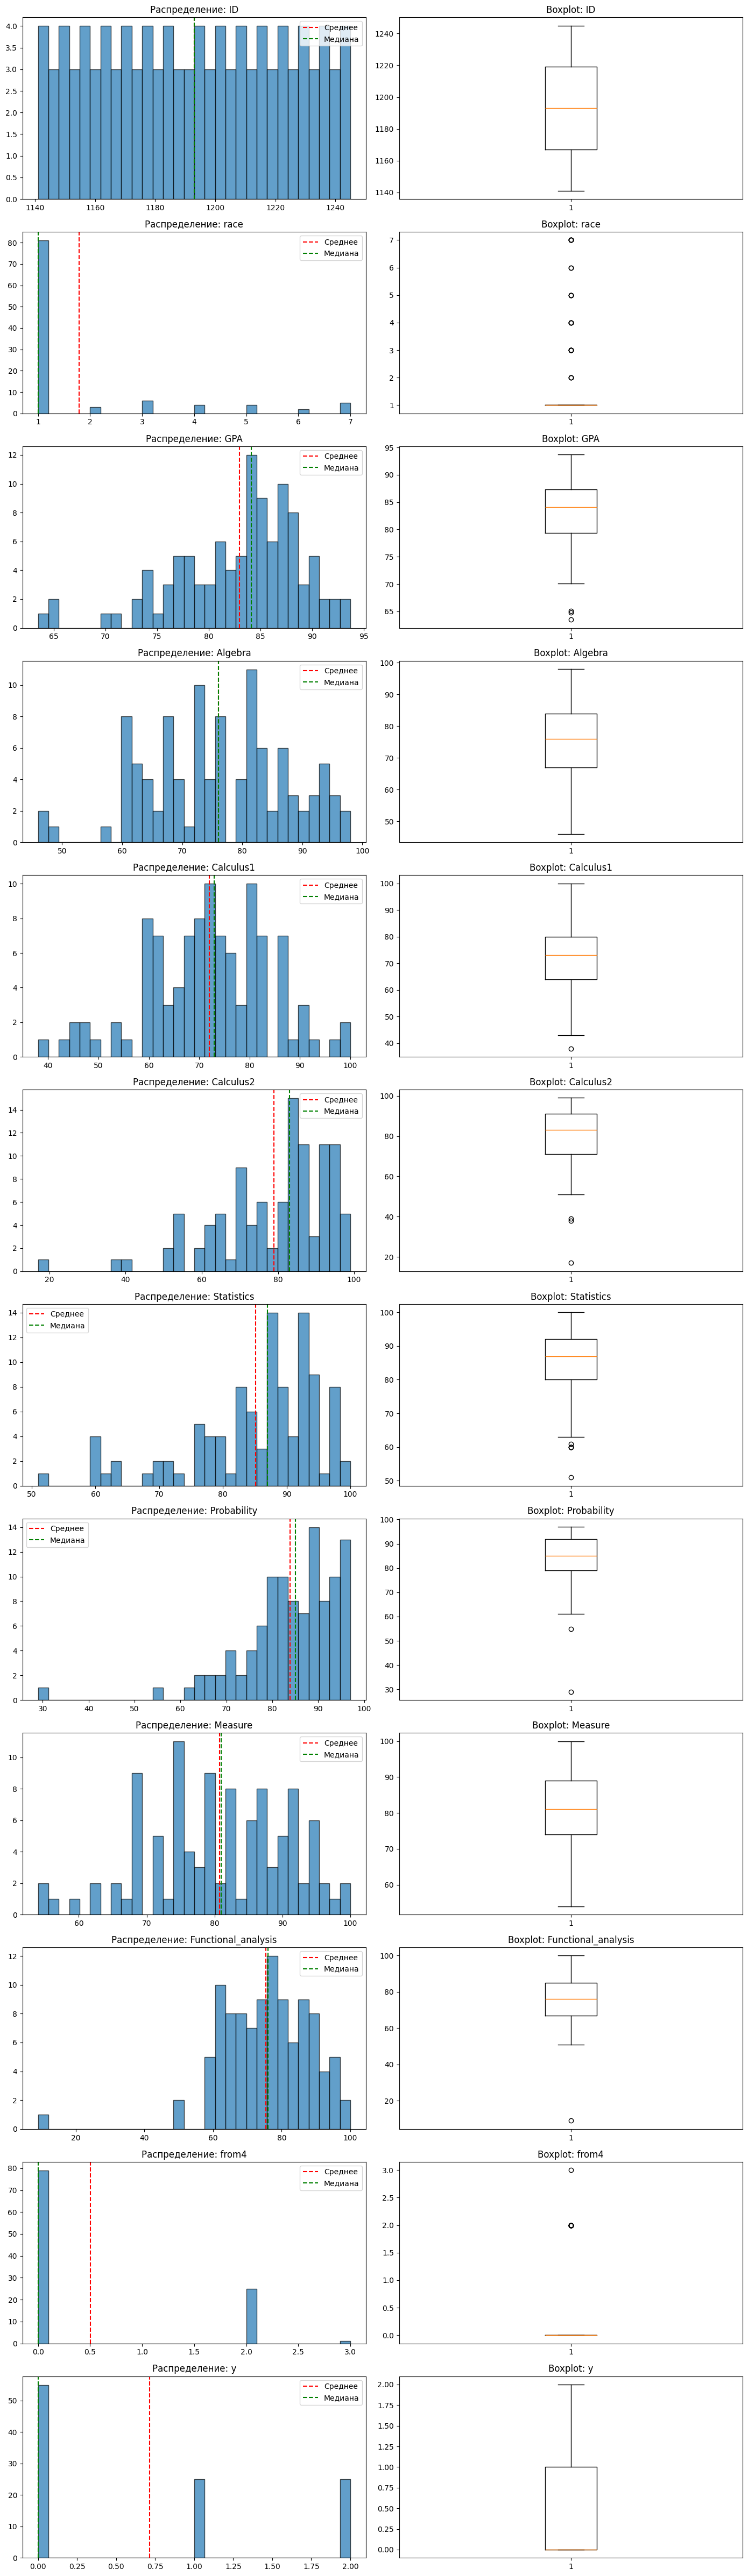

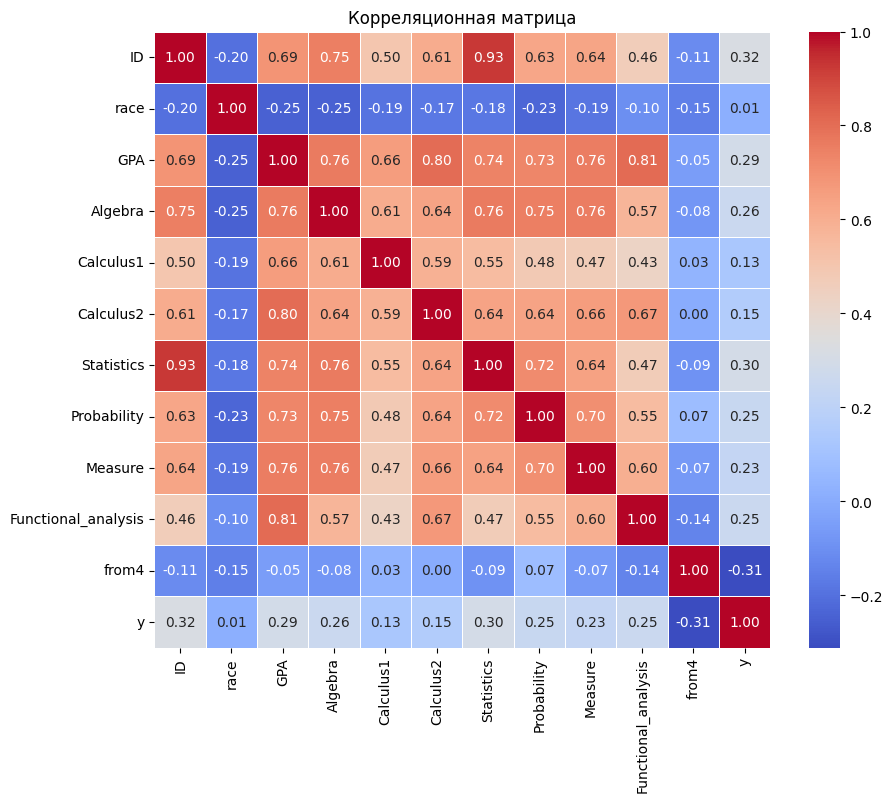


Топ-10 корреляций:
1. ID - Statistics: 0.925
2. Statistics - ID: 0.925
3. Functional_analysis - GPA: 0.809
4. GPA - Functional_analysis: 0.809
5. Calculus2 - GPA: 0.804
6. GPA - Calculus2: 0.804
7. Algebra - GPA: 0.762
8. GPA - Algebra: 0.762
9. Algebra - Statistics: 0.760
10. Statistics - Algebra: 0.760


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Распределения числовых признаков
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols)*4))
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    # Гистограмма
    axes[i][0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i][0].set_title(f'Распределение: {col}')
    axes[i][0].axvline(df[col].mean(), color='red', linestyle='--', label='Среднее')
    axes[i][0].axvline(df[col].median(), color='green', linestyle='--', label='Медиана')
    axes[i][0].legend()

    # Boxplot
    axes[i][1].boxplot(df[col].dropna())
    axes[i][1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Корреляционная матрица')
plt.show()

# Топ-5 корреляций
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
print("\nТоп-10 корреляций:")
for i, (pair, val) in enumerate(corr_pairs.head(10).items(), 1):
    print(f"{i}. {pair[0]} - {pair[1]}: {val:.3f}")

## Обработка выбросов

In [4]:
def cap_outliers(df, column):
    """Заменяет выбросы на границы IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_before = ((df[column] < lower) | (df[column] > upper)).sum()
    df[column] = df[column].clip(lower=lower, upper=upper)
    outliers_after = ((df[column] < lower) | (df[column] > upper)).sum()

    print(f"{column}: выбросов до: {outliers_before}, после: {outliers_after}")
    return df

# Колонки для обработки
cols_to_cap = ['race', 'GPA', 'Calculus2', 'Statistics', 'Probability', 'from4']
df_processed = df.copy()

for col in cols_to_cap:
    df_processed = cap_outliers(df_processed, col)

race: выбросов до: 24, после: 0
GPA: выбросов до: 3, после: 0
Calculus2: выбросов до: 3, после: 0
Statistics: выбросов до: 6, после: 0
Probability: выбросов до: 2, после: 0
from4: выбросов до: 26, после: 0


## Кодирование категориальных признаков (для обучения моделей)

In [10]:
df_encoded = df_processed.copy()

# One-Hot Encoding для бинарных категорий
df_encoded = pd.get_dummies(df_encoded, columns=['class', 'gender'], drop_first=True)
print(f"После One-Hot: {df_encoded.shape}")

# Frequency Encoding для многоклассовых категорий
def frequency_encoding(df, column):
    freq = df[column].value_counts(normalize=True)
    df[column + '_freq'] = df[column].map(freq)
    return df

for col in ['from1', 'from2', 'from3']:
    df_encoded = frequency_encoding(df_encoded, col)
    print(f"{col}_freq: {df_encoded[col + '_freq'].nunique()} уникальных значений")

# Удаляем исходные колонки
df_encoded = df_encoded.drop(columns=['from1', 'from2', 'from3'])
print(f"Итоговый размер: {df_encoded.shape}")

После One-Hot: (105, 17)
from1_freq: 9 уникальных значений
from2_freq: 2 уникальных значений
from3_freq: 4 уникальных значений
Итоговый размер: (105, 17)


## Feature Engineering (создание новых признаков)
* из предметных оценок были вычислены статистические показатели
* созданы признаки взаимодействия (gpa_class и gpa_gender), которые учитывают, как успеваемость GPA влияет на целевую переменную в зависимости от класса и пола студента

In [14]:
subject_cols = ['Algebra', 'Calculus1', 'Calculus2', 'Statistics', 'Probability', 'Measure', 'Functional_analysis']

# 1. Статистики по оценкам
df_encoded['avg_score'] = df_encoded[subject_cols].mean(axis=1)
df_encoded['std_score'] = df_encoded[subject_cols].std(axis=1)
df_encoded['min_score'] = df_encoded[subject_cols].min(axis=1)
df_encoded['max_score'] = df_encoded[subject_cols].max(axis=1)
df_encoded['range_score'] = df_encoded['max_score'] - df_encoded['min_score']

# 2. Взаимодействие признаков
df_encoded['gpa_class'] = df_encoded['GPA'] * df_encoded['class_B']
df_encoded['gpa_gender'] = df_encoded['GPA'] * df_encoded['gender_male']

# 3. Признаки из from4
import numpy as np
df_encoded['from4_binary'] = (df_encoded['from4'] > 0).astype(int)
df_encoded['from4_log'] = np.log1p(df_encoded['from4'])

print(f"Итоговый размер: {df_encoded.shape}")
print(f"\nНовые признаки:\n{df_encoded[['avg_score', 'std_score', 'min_score', 'max_score', 'range_score', 'gpa_class', 'gpa_gender', 'from4_binary', 'from4_log']].head()}")

Итоговый размер: (105, 29)

Новые признаки:
   avg_score  std_score  min_score  max_score  range_score  gpa_class  \
0  71.285714  10.127755       60.0       87.0         27.0        0.0   
1  57.500000   5.090841       50.0       62.0         12.0        0.0   
2  60.142857   9.299258       47.0       71.0         24.0        0.0   
3  55.071429  10.426043       41.0       72.0         31.0        0.0   
4  58.857143   8.395010       45.0       66.0         21.0        0.0   

   gpa_gender  from4_binary  from4_log  
0       73.47             0        0.0  
1        0.00             0        0.0  
2        0.00             0        0.0  
3        0.00             0        0.0  
4        0.00             0        0.0  


## Масштабирование и разделение данных
так как в линейных моделях веса зависят от масштаба, проведем масштабирование с помощью библиотеки sklearn. Разделение выборки возьмем 20 (test) к 80 (train).

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Определяем признаки и целевую переменную (искючаем идентификатор студента и целевую переменную из Х)
X = df_encoded.drop(columns=['ID', 'y'])
y = df_encoded['y']

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Признаков: {X_scaled.shape[1]}")
print(f"Целевая переменная: {y.name}")
print(f"Классы: {sorted(y.unique())}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=38, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape[0]}")
print(f"Тестовая выборка: {X_test.shape[0]}")
print(f"\nРаспределение y в train:\n{y_train.value_counts().sort_index()}")
print(f"\nРаспределение y в test:\n{y_test.value_counts().sort_index()}")

Признаков: 27
Целевая переменная: y
Классы: [np.int64(0), np.int64(1), np.int64(2)]

Обучающая выборка: 84
Тестовая выборка: 21

Распределение y в train:
y
0    44
1    20
2    20
Name: count, dtype: int64

Распределение y в test:
y
0    11
1     5
2     5
Name: count, dtype: int64


## Обучение ML моделей
(модели скорее всего обучаться плохо, так как данных мало)

## Логистическая регрессия

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5238
F1 (macro): 0.4058
F1 (weighted): 0.5042

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.82      0.75        11
           1       0.17      0.20      0.18         5
           2       0.50      0.20      0.29         5

    accuracy                           0.52        21
   macro avg       0.45      0.41      0.41        21
weighted avg       0.52      0.52      0.50        21

[[9 2 0]
 [3 1 1]
 [1 3 1]]


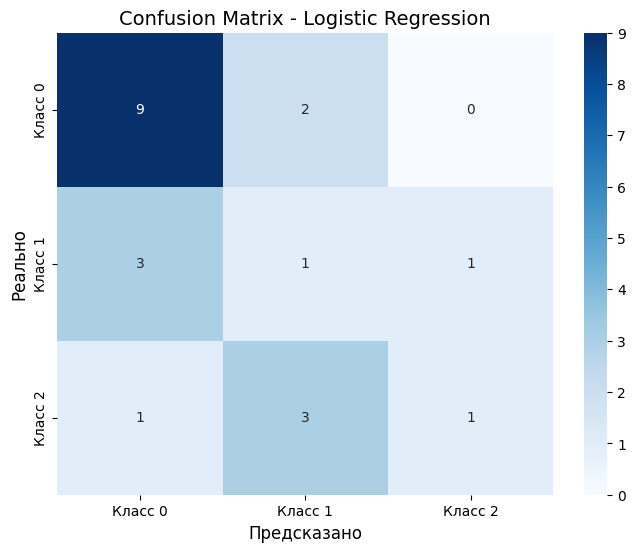

In [40]:
from sklearn.linear_model import LogisticRegression # модель лог регрессии
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, confusion_matrix # метрики классификации

logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=100000, C=1, random_state=38)

logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr)}")

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Класс 0', 'Класс 1', 'Класс 2'],
            yticklabels=['Класс 0', 'Класс 1', 'Класс 2'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Предсказано', fontsize=12)
plt.ylabel('Реально', fontsize=12)
plt.show()

## Random Forest

Accuracy: 0.5238
F1 (macro): 0.2366
F1 (weighted): 0.3717

Classification Report:
              precision    recall  f1-score   support

           0       0.55      1.00      0.71        11
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         5

    accuracy                           0.52        21
   macro avg       0.18      0.33      0.24        21
weighted avg       0.29      0.52      0.37        21


Топ-10 важнейших признаков:
        feature  importance
      avg_score    0.090217
            GPA    0.082973
       avg_easy    0.079951
        Measure    0.070839
      min_score    0.068703
      Calculus2    0.063776
        Algebra    0.059450
hard_easy_ratio    0.055900
      max_score    0.052773
     Statistics    0.049919
[[11  0  0]
 [ 5  0  0]
 [ 4  1  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


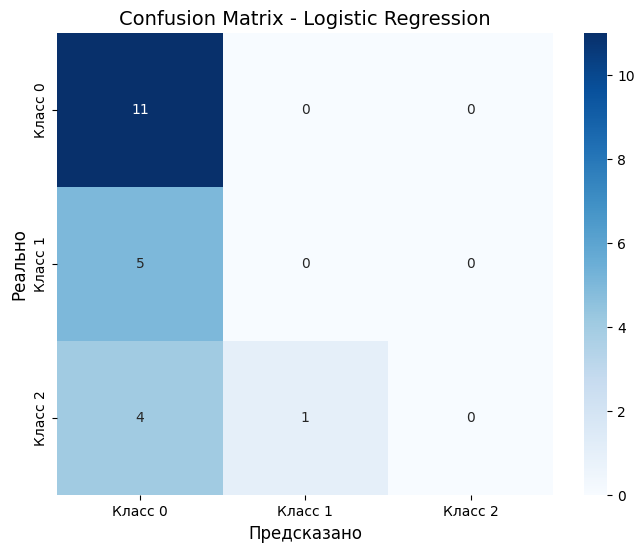

In [45]:
from  sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=38)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важнейших признаков:")
print(feature_importance.head(10).to_string(index=False))

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Класс 0', 'Класс 1', 'Класс 2'],
            yticklabels=['Класс 0', 'Класс 1', 'Класс 2'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Предсказано', fontsize=12)
plt.ylabel('Реально', fontsize=12)
plt.show()

Gradient Boosting

Accuracy: 0.2857
F1 (macro): 0.2056
F1 (weighted): 0.2659

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.45      0.42        11
           1       0.00      0.00      0.00         5
           2       0.20      0.20      0.20         5

    accuracy                           0.29        21
   macro avg       0.19      0.22      0.21        21
weighted avg       0.25      0.29      0.27        21

[[5 2 4]
 [5 0 0]
 [3 1 1]]


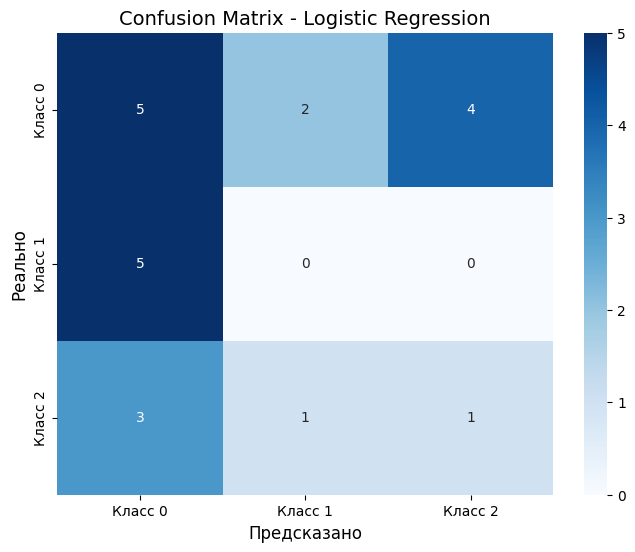

In [44]:
from  sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_gb)}")

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred_gb)
print(cm)
# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Класс 0', 'Класс 1', 'Класс 2'],
            yticklabels=['Класс 0', 'Класс 1', 'Класс 2'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Предсказано', fontsize=12)
plt.ylabel('Реально', fontsize=12)
plt.show()

## Выводы
Был проведён полный цикл анализа данных и построения базовых ML-моделей для прогнозирования успеваемости студентов. Были выявлены ключевые факторы, влияющие на академическую успеваемость и обоснована необходимость увеличения выборки для повышения качества прогнозов.